# Removing signal from noisy spikes by Median Filter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
signal = pd.read_csv('Spike.csv')
signal.head(10)

,-1.41E+00
0,-4.190
1,-2.240
2,-0.472
3,-2.490
4,0.784
5,-0.856
6,-1.380
7,0.595
8,-1.440
9,-2.470


In [6]:
signal = np.array(signal)
signal

array([[ -4.19 ],
       [ -2.24 ],
       [ -0.472],
       ...,
       [-37.1  ],
       [-38.1  ],
       [-40.7  ]], shape=(4999, 1))

In [9]:
spiky = abs(signal)  # usuwa wartości 0<
spiky

array([[ 4.19 ],
       [ 2.24 ],
       [ 0.472],
       ...,
       [37.1  ],
       [38.1  ],
       [40.7  ]], shape=(4999, 1))

In [11]:
spiky.shape

(4999, 1)

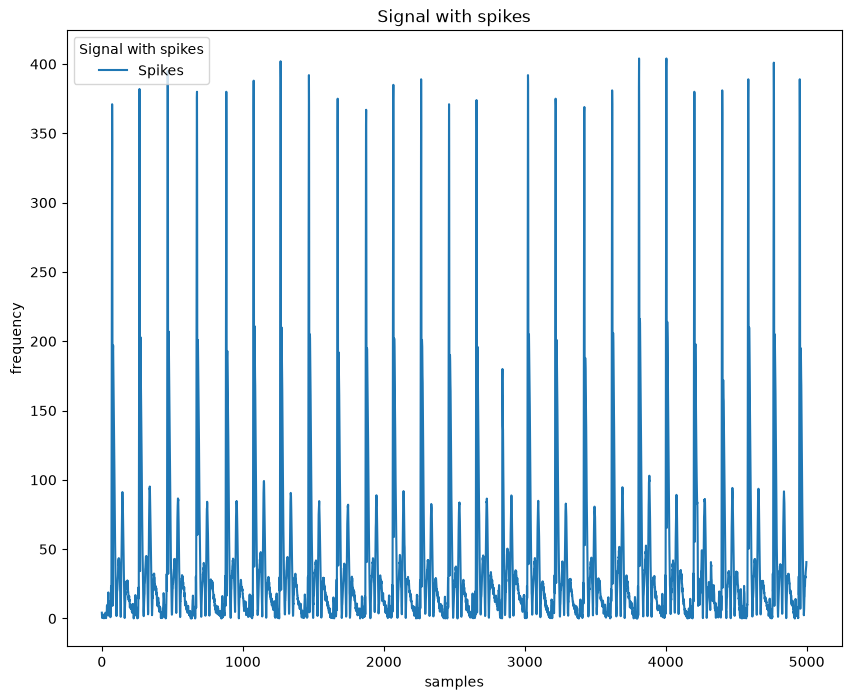

In [36]:
# PLotting 

fig, ax = plt.subplots(figsize=(10,8))   ### subplots nooot subplot 

# DATA
spikes = ax.plot(spiky)

# Settings 
ax.set(
    title = "Signal with spikes", 
    xlabel = "samples",
    ylabel = "frequency"
)

# Legend 
ax.legend(labels=["Spikes"], title="Signal with spikes")
plt.show();

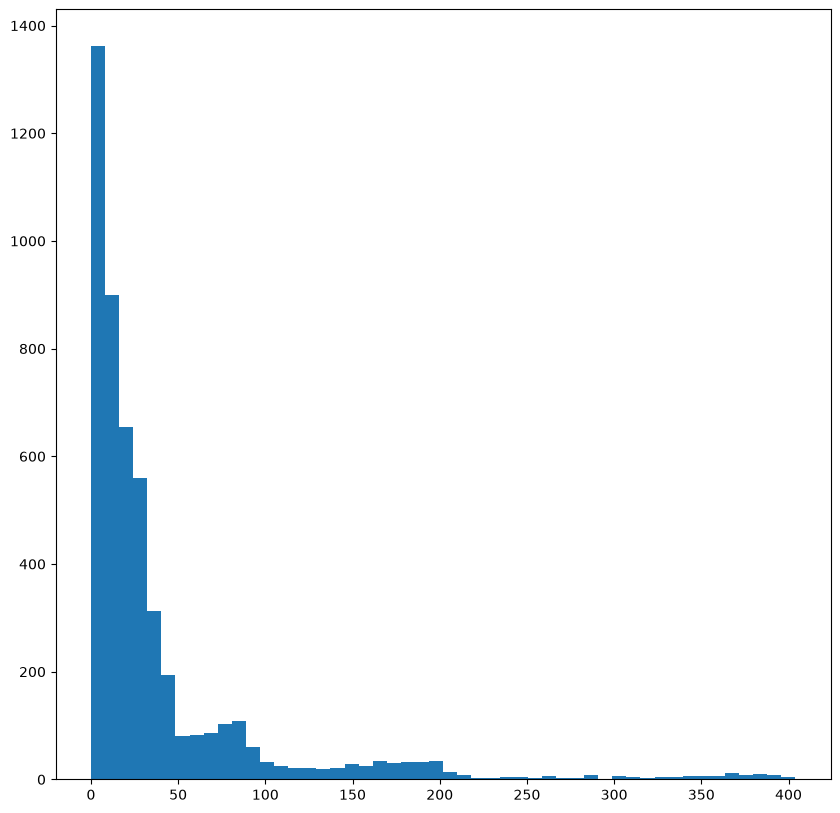

In [45]:
plt.figure(figsize=(10, 10))
plt.hist(spiky, 50)
plt.show();

## Using np.where to find the indices of spiky signal having magnitude greater than 50

In [49]:
threshold = 50
ultra_tresh = np.where(spiky>threshold)[0]
ultra_tresh

array([  69,   70,   71,   72,   73,   74,   75,   76,   78,   79,   80,
         81,   82,   83,   84,   85,   86,   87,   88,   89,   90,   91,
         92,   93,   94,  140,  141,  142,  143,  144,  145,  146,  147,
        148,  149,  150,  151,  152,  153,  263,  264,  265,  266,  267,
        268,  269,  270,  272,  273,  274,  275,  276,  277,  278,  279,
        280,  281,  282,  283,  284,  285,  286,  287,  288,  333,  334,
        335,  336,  337,  338,  339,  340,  341,  342,  343,  344,  345,
        346,  347,  463,  464,  465,  466,  467,  468,  469,  470,  472,
        473,  474,  475,  476,  477,  478,  479,  480,  481,  482,  483,
        484,  485,  486,  487,  488,  489,  534,  535,  536,  537,  538,
        539,  540,  541,  542,  543,  544,  545,  546,  547,  670,  671,
        672,  673,  674,  675,  676,  677,  678,  679,  680,  681,  682,
        683,  684,  685,  686,  687,  688,  689,  690,  691,  692,  693,
        694,  695,  696,  742,  743,  744,  745,  7

In [56]:
print(f"Amount of samples after filtering: {len(ultra_tresh)}" )

Amount of samples after filtering: 998


In [61]:
filtSignal = np.copy(spiky)

N = 100 


## APPLYING MEDIAN FILTER

for i in range(0, ultra_tresh.shape[0]):
    filtSignal[ultra_tresh[i]] = np.median(spiky[ultra_tresh[i]:ultra_tresh[i]+N])
    

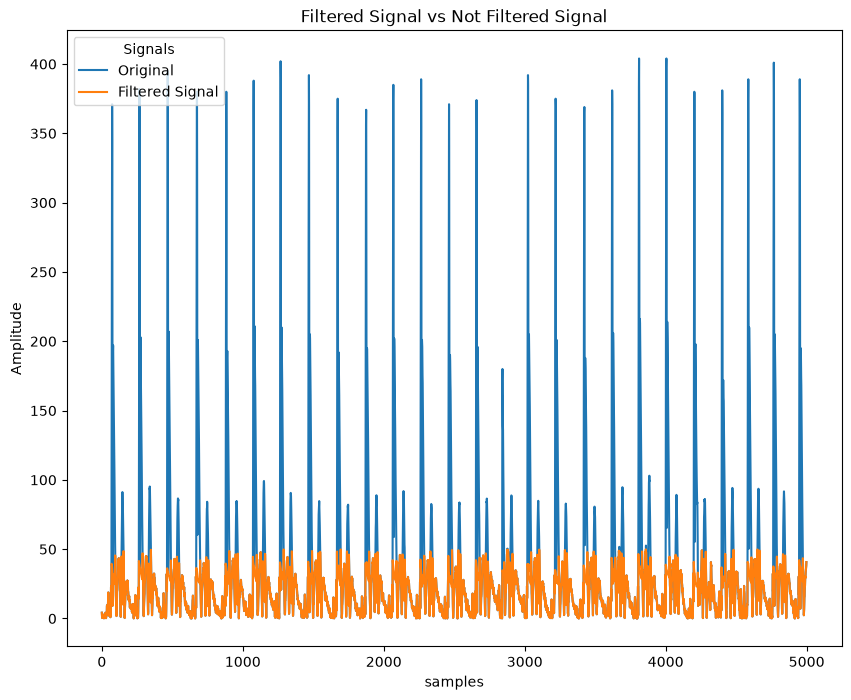

In [68]:
# PLotting 

fig, ax = plt.subplots(figsize=(10,8))   ### subplots nooot subplot 

# DATA
spikes = ax.plot(spiky, label="Original")
filtered = ax.plot(filtSignal, label="Filtered Signal")

# Settings 
ax.set(
    title = "Filtered Signal vs Not Filtered Signal", 
    xlabel = "samples",
    ylabel = "Amplitude"
)

# Legend 
ax.legend(title="Signals")
plt.show();